# HAI CUTLASS Coefficient Figures

This notebook loads the HAI parquet datasets created by `build_hai_cutlass_data.py`, fits two models with the `cutlass` package, and produces coefficient figures in the same general style as the legacy HAI screenshots:

- a **rectified / transformed** CUTLASS fit,
- a **raw / un-transformed** L1 logistic fit,
- grouped feature spans for `P1`, `P2`, `P3`, and `P4` instrument families.

Use the **`Python (cutlass)`** kernel or any kernel backed by the `cutlass` conda environment.

The dissertation / paper HAI figure uses the balanced **turbine / `P2`** subset with **2,552** training rows and **1,080** test rows. In the legacy `hai_20.07.R` naming, that subset is `a1`, so this notebook defaults to the clearer alias `attack_p2`.


In [1]:
from pathlib import Path
from time import perf_counter
import importlib
import inspect
import sys
import warnings

import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import roc_curve
from IPython.display import display

# Reload cutlass from the active environment so the notebook reflects the
# currently installed package rather than a previously cached module.
for module_name in [name for name in list(sys.modules) if name == 'cutlass' or name.startswith('cutlass.')]:
    del sys.modules[module_name]

cutlass = importlib.import_module('cutlass')
DuplicateColumnConsolidator = cutlass.DuplicateColumnConsolidator
Rectifier = cutlass.Rectifier
StandardScaler = cutlass.StandardScaler
CutlassLogisticCV = cutlass.CutlassLogisticCV
calculate_youden_j = cutlass.calculate_youden_j
roc_auc_score = cutlass.roc_auc_score
RECTIFIER_SIGNATURE = inspect.signature(Rectifier)
RECTIFIER_PARAMS = set(RECTIFIER_SIGNATURE.parameters)
CUTLASS_MODULE = Path(inspect.getfile(cutlass)).resolve()
RECTIFIER_SOURCE = Path(inspect.getfile(Rectifier)).resolve()
CONSOLIDATOR_SIGNATURE = inspect.signature(DuplicateColumnConsolidator)

warnings.filterwarnings('ignore', message='All-NaN slice encountered')
pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 20)
plt.style.use('seaborn-v0_8-white')

print('CUTLASS  :', CUTLASS_MODULE)
print('RECTIFY  :', RECTIFIER_SIGNATURE)
print('DEDUPE   :', CONSOLIDATOR_SIGNATURE)


CUTLASS  : C:\Users\jason\.conda\envs\cutlass\Lib\site-packages\cutlass\__init__.py
RECTIFY  : (groups: 'Optional[Mapping[str, Sequence[str]]]' = None, sdfilter: 'Optional[float]' = 3.0, snap: 'float' = 0.001, quantile_bounds: 'Optional[tuple[float, float]]' = None, add_complements: 'bool' = False, complement_prefix: 'str' = 'n', exclude_features: 'Sequence[str]' = ()) -> None
DEDUPE   : (mode: 'str' = 'within_group', expansion: 'str' = 'split_evenly') -> None


In [2]:
# Configuration
# Legacy R names are ambiguous for HAI. The paper / dissertation turbine figure
# is the balanced `a1` split, which corresponds to the clearer alias `attack_p2`.
TARGET_ALIASES = {
    'attack_p1': 'a0',
    'attack_p2': 'a1',
    'attack_p1p2': 'a2',
    'attack_p3': 'a3',
    'attack_p1p3': 'a4',
    'turbine': 'a1',
}
TARGET_GROUP_HINTS = {
    'attack_p1': 'P1',
    'a0': 'P1',
    'attack_p2': 'P2',
    'turbine': 'P2',
    'a1': 'P2',
    'attack_p3': 'P3',
    'a3': 'P3',
}
TARGET_KEY = 'attack_p2'
USE_BALANCED = True
HIGHLIGHT_GROUP = None
TRANSFORMED_MODEL_BACKEND = 'sklearn_l1'
FIXED_C_TRANSFORMED = 0.012
FIXED_C_RAW = None
TUNED_CUTLASS_FULL_PIPELINE_C = 0.010
TUNED_CUTLASS_FULL_PIPELINE_SOLVER = 'cd'
TUNED_CUTLASS_FULL_PIPELINE_MAX_ITER = 2000
TUNED_CUTLASS_FULL_PIPELINE_TOL = 1e-4
TUNED_CUTLASS_FULL_PIPELINE_ZERO_CLAMP = 0.0
TRANSFORMED_SKLEARN_SOLVER = 'saga'
TRANSFORMED_SKLEARN_MAX_ITER = 12000
TRANSFORMED_SKLEARN_RANDOM_STATE = 42
TRANSFORMED_SKLEARN_TOL = 1e-4
RAW_MODEL_BACKEND = 'sklearn_l1'
RAW_SKLEARN_SOLVER = 'saga'
RAW_SKLEARN_MAX_ITER = 12000
RAW_SKLEARN_RANDOM_STATE = 42
RAW_SKLEARN_TOL = 1e-4
RAW_SKLEARN_SCORING = 'roc_auc'

# HAI attack attribution is clearer in absolute transformed-effect space:
# strong attacked-loop terms can appear with negative sign on the original
# {-1,+1} indicators, so a positive-only view hides them.
TRANSFORMED_VIEW = 'effect_abs'

# The older HAI analysis path is closer to CUTLASS rectification plus a
# plain L1 logistic refit than to the newer CutlassLogisticCV solver path.
# Show the full transformed coefficient vector by default.
TRANSFORMED_PLOT_RELATIVE_CUTOFF = None
TRANSFORMED_PLOT_TOP_K = None

# Toggle CUTLASS logical polishing on or off for transformed CUTLASS paths.
USE_LOGIC_POLISH = False
LOGIC_POLISH_KW = dict(
    logic_scale=10.0,
    logic_intercept='mean',
    logic_rel_tol=0.01,
)

# The plain min/max rectifier on HAI `a1_sm` is brittle and tends to push the
# transformed model onto the wrong instruments. The paper explicitly allows
# robust quantiles when min/max is unstable. The legacy HAI R path did not
# use `addrev`, so complemented columns are off by default here.
USE_ROBUST_RECTIFICATION = True
ROBUST_QUANTILES = (0.35, 0.65)
ADD_COMPLEMENT_FEATURES = False
COMPLEMENT_PREFIX = 'n'

DUPLICATE_CONSOLIDATION_MODE = 'within_group'
DUPLICATE_EXPANSION_POLICY = 'split_evenly'

# CUTLASS settings chosen to keep the notebook reliable on Windows/Jupyter
# while still matching the dissertation HAI behavior closely.
if USE_ROBUST_RECTIFICATION and 'quantile_bounds' not in RECTIFIER_PARAMS:
    warnings.warn(
        'The active Rectifier does not support quantile_bounds. '
        'Restart the kernel after updating the installed cutlass package if you expected a newer API. '
        'Falling back to min/max rectification for this run.'
    )
    USE_ROBUST_RECTIFICATION = False

if ADD_COMPLEMENT_FEATURES and 'add_complements' not in RECTIFIER_PARAMS:
    warnings.warn(
        'The active Rectifier does not support complement features. '
        'Restart the kernel after updating the installed cutlass package if you expected a newer API. '
        'Proceeding without complemented columns for this run.'
    )
    ADD_COMPLEMENT_FEATURES = False

if TRANSFORMED_MODEL_BACKEND not in {'cutlass_l1', 'sklearn_l1'}:
    raise ValueError('TRANSFORMED_MODEL_BACKEND must be cutlass_l1 or sklearn_l1.')
if TRANSFORMED_MODEL_BACKEND == 'sklearn_l1' and FIXED_C_TRANSFORMED is None:
    raise ValueError('The sklearn_l1 transformed backend requires FIXED_C_TRANSFORMED.')
if TRANSFORMED_MODEL_BACKEND == 'sklearn_l1' and USE_LOGIC_POLISH:
    warnings.warn(
        'Logic polishing is only applied by the cutlass_l1 transformed backend. '
        'The transformed sklearn_l1 fit will ignore USE_LOGIC_POLISH.'
    )
if DUPLICATE_CONSOLIDATION_MODE not in {'none', 'within_group', 'global'}:
    raise ValueError('DUPLICATE_CONSOLIDATION_MODE must be none, within_group, or global.')
if DUPLICATE_EXPANSION_POLICY not in {'split_evenly', 'representative_only'}:
    raise ValueError('DUPLICATE_EXPANSION_POLICY must be split_evenly or representative_only.')

RECTIFIER_KW = dict(
    sdfilter=None,
    snap=0.001,
)
if USE_ROBUST_RECTIFICATION:
    RECTIFIER_KW['quantile_bounds'] = ROBUST_QUANTILES
if ADD_COMPLEMENT_FEATURES:
    RECTIFIER_KW['add_complements'] = True
    if 'complement_prefix' in RECTIFIER_PARAMS:
        RECTIFIER_KW['complement_prefix'] = COMPLEMENT_PREFIX
CV_KW = dict(
    Cs=10,
    cv=3,
    n_jobs=1,
    tol=1e-4,
    max_iter=1200,
    random_state=42,
    verbose=False,
    refit=True,
    cv_rule='1se',
)

# Resolve the HAI case directory whether the notebook is launched from the repo
# root or from the case directory itself.
CANDIDATES = [
    Path.cwd(),
    Path.cwd() / 'cases' / 'HAI',
    Path(r'C:\Users\jason\ODU\cutlass_demo\cases\HAI'),
]
BASE_DIR = None
for candidate in CANDIDATES:
    if (candidate / 'processed_data').exists():
        BASE_DIR = candidate.resolve()
        break
if BASE_DIR is None:
    raise FileNotFoundError('Could not locate cases/HAI/processed_data. Run build_hai_cutlass_data.py first.')

DATA_DIR = BASE_DIR / 'processed_data'
FIG_DIR = BASE_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

TARGET_RESOLVED_KEY = TARGET_ALIASES.get(TARGET_KEY, TARGET_KEY)
split_suffix = '_sm' if USE_BALANCED else ''
PLOT_HIGHLIGHT_GROUP = (
    HIGHLIGHT_GROUP
    or TARGET_GROUP_HINTS.get(TARGET_KEY)
    or TARGET_GROUP_HINTS.get(TARGET_RESOLVED_KEY)
)
TRAIN_PATH = DATA_DIR / f'train_{TARGET_RESOLVED_KEY}{split_suffix}_hai.parquet'
TEST_PATH = DATA_DIR / f'test_{TARGET_RESOLVED_KEY}{split_suffix}_hai.parquet'

print('BASE_DIR :', BASE_DIR)
print('TARGET   :', TARGET_KEY, '->', TARGET_RESOLVED_KEY)
print('TRAIN    :', TRAIN_PATH.name)
print('TEST     :', TEST_PATH.name)
print('FIG_DIR  :', FIG_DIR)
print('HILITE   :', PLOT_HIGHLIGHT_GROUP)
print('MODEL +  :', TRANSFORMED_MODEL_BACKEND)
print('MODEL -  :', RAW_MODEL_BACKEND)
print('FIXED C+ :', FIXED_C_TRANSFORMED)
print('FIXED C- :', FIXED_C_RAW)
print('SOLVER - :', RAW_SKLEARN_SOLVER)
print('VIEW     :', TRANSFORMED_VIEW)
print('PLOT CUT :', TRANSFORMED_PLOT_RELATIVE_CUTOFF)
print('PLOT TOPK:', TRANSFORMED_PLOT_TOP_K)
print('DEDUPE   :', DUPLICATE_CONSOLIDATION_MODE)
print('EXPAND   :', DUPLICATE_EXPANSION_POLICY)
print('LOGIC    :', 'on' if USE_LOGIC_POLISH else 'off')
print('ROBUST   :', ROBUST_QUANTILES if USE_ROBUST_RECTIFICATION else 'min/max')
print('ADD REV  :', ADD_COMPLEMENT_FEATURES)
print('KW       :', RECTIFIER_KW)


BASE_DIR : C:\Users\jason\ODU\dissertation\notebooks
TARGET   : attack_p2 -> a1
TRAIN    : train_a1_sm_hai.parquet
TEST     : test_a1_sm_hai.parquet
FIG_DIR  : C:\Users\jason\ODU\dissertation\notebooks\figures
HILITE   : P2
MODEL +  : sklearn_l1
MODEL -  : sklearn_l1
FIXED C+ : 0.012
FIXED C- : None
SOLVER - : saga
VIEW     : effect_abs
PLOT CUT : None
PLOT TOPK: None
DEDUPE   : within_group
EXPAND   : split_evenly
LOGIC    : off
ROBUST   : (0.35, 0.65)
ADD REV  : False
KW       : {'sdfilter': None, 'snap': 0.001, 'quantile_bounds': (0.35, 0.65)}


In [3]:
RESP = 'INDC'
GROUP_LABELS = {
    'P1': 'P1 Instruments',
    'P2': 'P2',
    'P3': 'P3',
    'P4': 'P4',
}


def load_hai_split(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_parquet(path)


def canonical_feature_name(feature_name: str) -> str:
    if ADD_COMPLEMENT_FEATURES and feature_name.startswith(COMPLEMENT_PREFIX):
        candidate = feature_name[len(COMPLEMENT_PREFIX):]
        if '_' in candidate:
            return candidate
    return feature_name


def root_group(feature_name: str) -> str:
    return canonical_feature_name(feature_name).split('_', 1)[0]


def collapse_augmented_coefficients(
    coef_full: pd.Series,
    base_features: list[str],
) -> tuple[pd.Series, pd.Series, pd.Series, pd.Series]:
    effect = pd.Series(0.0, index=base_features, name='coef')
    effect_abs = pd.Series(0.0, index=base_features, name='coef')
    positive = pd.Series(0.0, index=base_features, name='coef')
    support = pd.Series(0.0, index=base_features, name='coef')
    for feature in base_features:
        base_coef = float(coef_full.get(feature, 0.0))
        comp_coef = 0.0
        if ADD_COMPLEMENT_FEATURES:
            comp_name = f'{COMPLEMENT_PREFIX}{feature}'
            comp_coef = float(coef_full.get(comp_name, 0.0))
        effect.loc[feature] = base_coef - comp_coef
        effect_abs.loc[feature] = abs(base_coef - comp_coef)
        positive.loc[feature] = max(base_coef, comp_coef, 0.0)
        support.loc[feature] = max(abs(base_coef), abs(comp_coef))
    return effect, effect_abs, positive, support


def group_spans(feature_order: list[str]) -> list[tuple[str, int, int]]:
    spans: list[tuple[str, int, int]] = []
    current = root_group(feature_order[0])
    start = 0
    for idx, name in enumerate(feature_order[1:], start=1):
        group = root_group(name)
        if group != current:
            spans.append((current, start, idx - 1))
            current = group
            start = idx
    spans.append((current, start, len(feature_order) - 1))
    return spans


def coefficient_group_share(coef: pd.Series, group: str, feature_order: list[str]) -> float:
    coef_abs = coef.abs().reindex(feature_order).fillna(0.0)
    total = float(coef_abs.sum())
    if total == 0.0:
        return 0.0
    mask = coef_abs.index.to_series().str.startswith(f'{group}_').to_numpy()
    return float(coef_abs.to_numpy()[mask].sum() / total)


def coefficient_group_summary(coef: pd.Series) -> pd.DataFrame:
    frame = pd.DataFrame({'coef': coef})
    frame['group'] = frame.index.map(root_group)
    grouped = frame.groupby('group')
    summary = pd.DataFrame(
        {
            'nonzero_count': grouped['coef'].apply(lambda s: int((s != 0).sum())),
            'abs_sum': grouped['coef'].apply(lambda s: float(s.abs().sum())),
            'max_abs': grouped['coef'].apply(lambda s: float(s.abs().max())),
        }
    )
    return summary.sort_values(['nonzero_count', 'abs_sum'], ascending=False)


def filter_transformed_for_plot(coef: pd.Series) -> pd.Series:
    filtered = coef.copy()
    if TRANSFORMED_PLOT_RELATIVE_CUTOFF is not None:
        max_abs = float(filtered.abs().max()) if len(filtered) else 0.0
        if max_abs > 0.0:
            min_keep = TRANSFORMED_PLOT_RELATIVE_CUTOFF * max_abs
            filtered.loc[filtered.abs() < min_keep] = 0.0
    if TRANSFORMED_PLOT_TOP_K is not None:
        top_k = int(TRANSFORMED_PLOT_TOP_K)
        if top_k > 0:
            keep = filtered.abs().sort_values(ascending=False).head(top_k).index
            filtered.loc[~filtered.index.isin(keep)] = 0.0
    return filtered


def summarize_quantile_bounds(rectifier_kw: dict | None = None, *, quantile_bounds: tuple[float, float] | None = None) -> str:
    bounds = quantile_bounds if quantile_bounds is not None else (rectifier_kw or {}).get('quantile_bounds')
    if bounds is None:
        return 'min/max'
    return f'{float(bounds[0]):.2f}-{float(bounds[1]):.2f}'


def build_summary_text(items: list[tuple[str, object]]) -> str:
    lines: list[str] = []
    for label, value in items:
        if value is None:
            continue
        if isinstance(value, float):
            rendered = f'{value:.3f}' if abs(value) >= 1e-3 else f'{value:.1e}'
        else:
            rendered = str(value)
        lines.append(f'{label}: {rendered}')
    return '\n'.join(lines)



def build_cv_kwargs(fixed_c: float | None = None) -> dict:
    kwargs = dict(CV_KW, logic_polish=USE_LOGIC_POLISH, **LOGIC_POLISH_KW)
    if fixed_c is not None:
        kwargs['Cs'] = [float(fixed_c)]
        kwargs['cv_rule'] = 'min'
    return kwargs


def duplicate_report_dict(consolidator: DuplicateColumnConsolidator) -> dict:
    return {
        'mode': consolidator.mode,
        'expansion': consolidator.expansion,
        'input_features': int(consolidator.n_input_features_),
        'fit_features': int(consolidator.n_output_features_),
        'duplicate_groups': int(consolidator.duplicate_group_count_),
        'duplicate_cols_removed': int(consolidator.duplicate_cols_removed_),
        'cross_group_alias_classes': int(consolidator.cross_group_alias_classes_),
    }


def prepare_rectified_design(X_train: pd.DataFrame, y_train: np.ndarray, X_test: pd.DataFrame, *, rectifier_kw: dict | None = None, duplicate_mode: str | None = None) -> dict:
    active_rectifier_kw = dict(RECTIFIER_KW if rectifier_kw is None else rectifier_kw)
    active_duplicate_mode = DUPLICATE_CONSOLIDATION_MODE if duplicate_mode is None else duplicate_mode
    rectifier = Rectifier(groups=None, **active_rectifier_kw)
    X_train_rect = rectifier.fit_transform(X_train, y_train)
    X_test_rect = rectifier.transform(X_test)
    consolidator = DuplicateColumnConsolidator(mode=active_duplicate_mode, expansion=DUPLICATE_EXPANSION_POLICY)
    X_train_fit = consolidator.fit_transform(X_train_rect, feature_names=rectifier.feature_names_)
    X_test_fit = consolidator.transform(X_test_rect, feature_names=rectifier.feature_names_)
    return {
        'rectifier': rectifier,
        'consolidator': consolidator,
        'rectifier_kw': active_rectifier_kw,
        'duplicate_mode': active_duplicate_mode,
        'X_train_rect': X_train_rect,
        'X_test_rect': X_test_rect,
        'rectified_feature_names': list(rectifier.feature_names_),
        'X_train_fit': X_train_fit,
        'X_test_fit': X_test_fit,
        'fit_feature_names': list(consolidator.feature_names_),
    }


def build_transformed_result(*, design: dict, classifier, X_base_columns: list[str], y_true: np.ndarray, model_name: str, backend: str, chosen_c: float, wall_seconds: float, solver_label: str, view: str | None = None, coef_fit_override: pd.Series | None = None, coef_full_override: pd.Series | None = None, prob_override: np.ndarray | None = None, pred_override: np.ndarray | None = None) -> dict:
    if coef_fit_override is None:
        coef_fit = pd.Series(classifier.coef_.ravel(), index=design['fit_feature_names'], name='coef')
    else:
        coef_fit = coef_fit_override.reindex(design['fit_feature_names']).fillna(0.0).rename('coef')

    if coef_full_override is None:
        coef_full = design['consolidator'].expand_coefficients(coef_fit)
    else:
        coef_full = coef_full_override.reindex(design['rectified_feature_names']).fillna(0.0).rename('coef')

    coef_effect, coef_effect_abs, coef_positive, coef_support = collapse_augmented_coefficients(coef_full, X_base_columns)
    transformed_views = {'effect': coef_effect, 'effect_abs': coef_effect_abs, 'positive': coef_positive, 'support': coef_support}
    selected_view = TRANSFORMED_VIEW if view is None else view
    coef = transformed_views.get(selected_view, coef_effect_abs)

    if prob_override is None:
        prob = classifier.predict_proba(design['X_test_fit'])[:, 1]
    else:
        prob = np.asarray(prob_override, dtype=np.float64)

    if pred_override is None:
        pred = (prob >= 0.5).astype(int)
    else:
        pred = np.asarray(pred_override, dtype=int)

    duplicate_report = duplicate_report_dict(design['consolidator'])
    metrics = {
        'model': model_name,
        'backend': backend,
        'solver': solver_label,
        'roc_auc': float(roc_auc_score(y_true, prob)),
        'youden_j': float(calculate_youden_j(y_true, pred)),
        'chosen_C': float(chosen_c),
        'nonzero_coef': int((coef != 0).sum()),
        'nonzero_coef_full': int((coef_full != 0).sum()),
        'nonzero_coef_fit': int((coef_fit != 0).sum()),
        'wall_seconds': float(wall_seconds),
        **duplicate_report,
    }
    return {
        'rectifier': design['rectifier'],
        'consolidator': design['consolidator'],
        'classifier': classifier,
        'coef': coef,
        'coef_fit': coef_fit,
        'coef_effect_abs': coef_effect_abs,
        'coef_positive': coef_positive,
        'coef_support': coef_support,
        'coef_effect': coef_effect,
        'coef_full': coef_full,
        'prob': prob,
        'pred': pred,
        'metrics': metrics,
        'duplicate_report': duplicate_report,
        'rectifier_kw': design['rectifier_kw'],
    }


def fit_rectified_model(X_train: pd.DataFrame, y_train: np.ndarray, X_test: pd.DataFrame) -> dict:
    wall_start = perf_counter()
    design = prepare_rectified_design(X_train, y_train, X_test)
    if TRANSFORMED_MODEL_BACKEND == 'sklearn_l1':
        lr = LogisticRegression(
            penalty='l1',
            solver=TRANSFORMED_SKLEARN_SOLVER,
            C=float(FIXED_C_TRANSFORMED),
            max_iter=TRANSFORMED_SKLEARN_MAX_ITER,
            random_state=TRANSFORMED_SKLEARN_RANDOM_STATE,
            tol=TRANSFORMED_SKLEARN_TOL,
        )
        lr.fit(design['X_train_fit'], y_train)
        chosen_c = float(FIXED_C_TRANSFORMED)
        solver_label = TRANSFORMED_SKLEARN_SOLVER
    else:
        lr = CutlassLogisticCV(**build_cv_kwargs(FIXED_C_TRANSFORMED))
        lr.fit(design['X_train_fit'], y_train)
        chosen_c = float(lr.C_)
        solver_label = 'CutlassLogisticCV'
    wall_seconds = perf_counter() - wall_start
    return build_transformed_result(
        design=design,
        classifier=lr,
        X_base_columns=list(X_train.columns),
        y_true=y_test,
        model_name='Transformed',
        backend=TRANSFORMED_MODEL_BACKEND,
        chosen_c=chosen_c,
        wall_seconds=wall_seconds,
        solver_label=solver_label,
    )


def fit_raw_model(X_train: pd.DataFrame, y_train: np.ndarray, X_test: pd.DataFrame) -> dict:
    wall_start = perf_counter()
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train.to_numpy(dtype=np.float64))
    X_test_scaled = scaler.transform(X_test.to_numpy(dtype=np.float64))

    if FIXED_C_RAW is None:
        lr = LogisticRegressionCV(
            penalty='l1',
            solver=RAW_SKLEARN_SOLVER,
            Cs=CV_KW['Cs'],
            cv=CV_KW['cv'],
            scoring=RAW_SKLEARN_SCORING,
            n_jobs=CV_KW['n_jobs'],
            max_iter=RAW_SKLEARN_MAX_ITER,
            random_state=RAW_SKLEARN_RANDOM_STATE,
            tol=RAW_SKLEARN_TOL,
            refit=True,
        )
        solver_label = f'{RAW_SKLEARN_SOLVER} cv'
    else:
        lr = LogisticRegression(
            penalty='l1',
            solver=RAW_SKLEARN_SOLVER,
            C=float(FIXED_C_RAW),
            max_iter=RAW_SKLEARN_MAX_ITER,
            random_state=RAW_SKLEARN_RANDOM_STATE,
            tol=RAW_SKLEARN_TOL,
        )
        solver_label = RAW_SKLEARN_SOLVER

    lr.fit(X_train_scaled, y_train)
    wall_seconds = perf_counter() - wall_start

    chosen_c = float(np.asarray(lr.C_).ravel()[0]) if hasattr(lr, 'C_') else float(FIXED_C_RAW)
    coef = pd.Series(lr.coef_.ravel(), index=X_train.columns, name='coef')
    prob = lr.predict_proba(X_test_scaled)[:, 1]
    pred = (prob >= 0.5).astype(int)
    metrics = {
        'model': 'Un-Transformed',
        'backend': RAW_MODEL_BACKEND,
        'solver': solver_label,
        'roc_auc': float(roc_auc_score(y_test, prob)),
        'youden_j': float(calculate_youden_j(y_test, pred)),
        'chosen_C': float(chosen_c),
        'nonzero_coef': int((coef != 0).sum()),
        'nonzero_coef_full': int((coef != 0).sum()),
        'wall_seconds': float(wall_seconds),
    }
    return {
        'scaler': scaler,
        'classifier': lr,
        'coef': coef,
        'prob': prob,
        'pred': pred,
        'metrics': metrics,
    }


def _draw_group_spans(ax: plt.Axes, spans: list[tuple[str, int, int]], *, highlight_group: str | None = None) -> None:
    trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
    y_arrow = -0.17
    y_text = -0.24
    for group, start, end in spans:
        color = 'red' if group == highlight_group else 'black'
        label = GROUP_LABELS.get(group, group)
        ax.annotate(
            '',
            xy=(start - 0.5, y_arrow),
            xytext=(end + 0.5, y_arrow),
            xycoords=trans,
            textcoords=trans,
            arrowprops=dict(arrowstyle='|-|', lw=1.6, color=color, shrinkA=0.0, shrinkB=0.0),
            annotation_clip=False,
        )
        ax.text(
            (start + end) / 2,
            y_text,
            label,
            transform=trans,
            ha='center',
            va='top',
            fontsize=12,
            color=color,
            fontweight='bold' if group == highlight_group else None,
        )


def plot_hai_coefficient_figure(
    coef_transformed: pd.Series,
    coef_raw: pd.Series,
    feature_order: list[str],
    *,
    highlight_group: str | None = 'P2',
    figure_title: str | None = None,
    transformed_summary: str | None = None,
    raw_summary: str | None = None,
) -> plt.Figure:
    spans = group_spans(feature_order)
    coef_transformed = coef_transformed.reindex(feature_order).fillna(0.0)
    coef_raw = coef_raw.reindex(feature_order).fillna(0.0)

    # The transformed coefficients are already collapsed back to the base
    # sensor axis in the selected view mode. Filter the small tail in the
    # top panel so HAI support concentration is visually readable.
    transformed_for_plot = filter_transformed_for_plot(coef_transformed)

    x = np.arange(len(feature_order))
    fig, axes = plt.subplots(
        2,
        1,
        figsize=(14, 9),
        sharex=True,
        gridspec_kw={'height_ratios': [1.0, 1.0], 'hspace': 0.72},
    )

    rect_span = float(max(1.0, np.abs(transformed_for_plot).max() * 1.15))
    rect_has_negative = bool((transformed_for_plot < 0).any())
    raw_span = float(max(1.0, np.abs(coef_raw).max() * 1.15))

    axes[0].bar(x, transformed_for_plot.to_numpy(), width=0.85, color='black', edgecolor='black', linewidth=0.4)
    if rect_has_negative:
        axes[0].axhline(0.0, color='black', linewidth=1.0)
        axes[0].set_ylim(-rect_span, rect_span)
    else:
        axes[0].set_ylim(0.0, rect_span)
    axes[0].set_ylabel('Coefficient Value')
    axes[0].text(0.01, 0.90, 'HAI Transformed', transform=axes[0].transAxes, fontsize=18, fontweight='bold')
    if transformed_summary:
        axes[0].text(
            0.99,
            0.97,
            transformed_summary,
            transform=axes[0].transAxes,
            ha='right',
            va='top',
            fontsize=9,
            bbox=dict(boxstyle='round,pad=0.35', fc='white', ec='0.55', alpha=0.92),
        )

    axes[1].bar(x, coef_raw.to_numpy(), width=0.85, color='black', edgecolor='black', linewidth=0.4)
    axes[1].axhline(0.0, color='black', linewidth=1.0)
    axes[1].set_ylim(-raw_span, raw_span)
    axes[1].set_ylabel('Coefficient Value')
    axes[1].text(0.01, 0.90, 'HAI Un-Transformed', transform=axes[1].transAxes, fontsize=18, fontweight='bold')
    if raw_summary:
        axes[1].text(
            0.99,
            0.97,
            raw_summary,
            transform=axes[1].transAxes,
            ha='right',
            va='top',
            fontsize=9,
            bbox=dict(boxstyle='round,pad=0.35', fc='white', ec='0.55', alpha=0.92),
        )

    for ax in axes:
        for _, start, _ in spans[1:]:
            ax.axvline(start - 0.5, color='0.65', linewidth=1.0)
        ax.set_xticks([])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    _draw_group_spans(axes[0], spans, highlight_group=highlight_group)
    if highlight_group is not None:
        span_lookup = {group: (start, end) for group, start, end in spans}
        if highlight_group in span_lookup:
            start, end = span_lookup[highlight_group]
            mid = (start + end) / 2
            axes[0].annotate(
                f'"{highlight_group}" indicates\nthat instrument group',
                xy=(mid, 0.0 if rect_has_negative else rect_span * 0.02),
                xycoords='data',
                xytext=(0.22, 0.74),
                textcoords='axes fraction',
                ha='left',
                va='top',
                fontsize=15,
                arrowprops=dict(arrowstyle='->', color='red', lw=2.0),
            )

    if figure_title:
        fig.suptitle(figure_title, fontsize=18, fontweight='bold', y=0.98)
        fig.subplots_adjust(top=0.92)
    fig.text(0.52, 0.025, 'Instrument Features', ha='center', fontsize=16)
    return fig


In [4]:
train_df = load_hai_split(TRAIN_PATH)
test_df = load_hai_split(TEST_PATH)

print('train shape:', train_df.shape)
print('test shape :', test_df.shape)
print('positive train examples:', int(train_df[RESP].sum()))
print('positive test examples :', int(test_df[RESP].sum()))

X_train = train_df.drop(columns=[RESP])
y_train = train_df[RESP].astype(int).to_numpy()
X_test = test_df.drop(columns=[RESP])
y_test = test_df[RESP].astype(int).to_numpy()
feature_order = list(X_train.columns)


train shape: (2552, 591)
test shape : (1080, 591)
positive train examples: 1276
positive test examples : 540


In [5]:
rect_result = fit_rectified_model(X_train, y_train, X_test)
raw_result = fit_raw_model(X_train, y_train, X_test)

metrics_df = pd.DataFrame([rect_result['metrics'], raw_result['metrics']]).set_index('model')
metrics_df = metrics_df.round({'roc_auc': 4, 'youden_j': 4, 'chosen_C': 6, 'wall_seconds': 3})
display(metrics_df)


,backend,solver,roc_auc,youden_j,chosen_C,nonzero_coef,nonzero_coef_full,nonzero_coef_fit,wall_seconds,mode,expansion,input_features,fit_features,duplicate_groups,duplicate_cols_removed,cross_group_alias_classes
model,,,,,,,,,,,,,,,,
Transformed,sklearn_l1,saga,0.9895,0.9296,0.012000,57,57,39.0,0.783,within_group,split_evenly,590.0,459.0,11.0,131.0,1.0
Un-Transformed,sklearn_l1,saga cv,0.8833,0.4759,0.005995,12,12,NaN,374.051,NaN,NaN,NaN,NaN,NaN,NaN,NaN


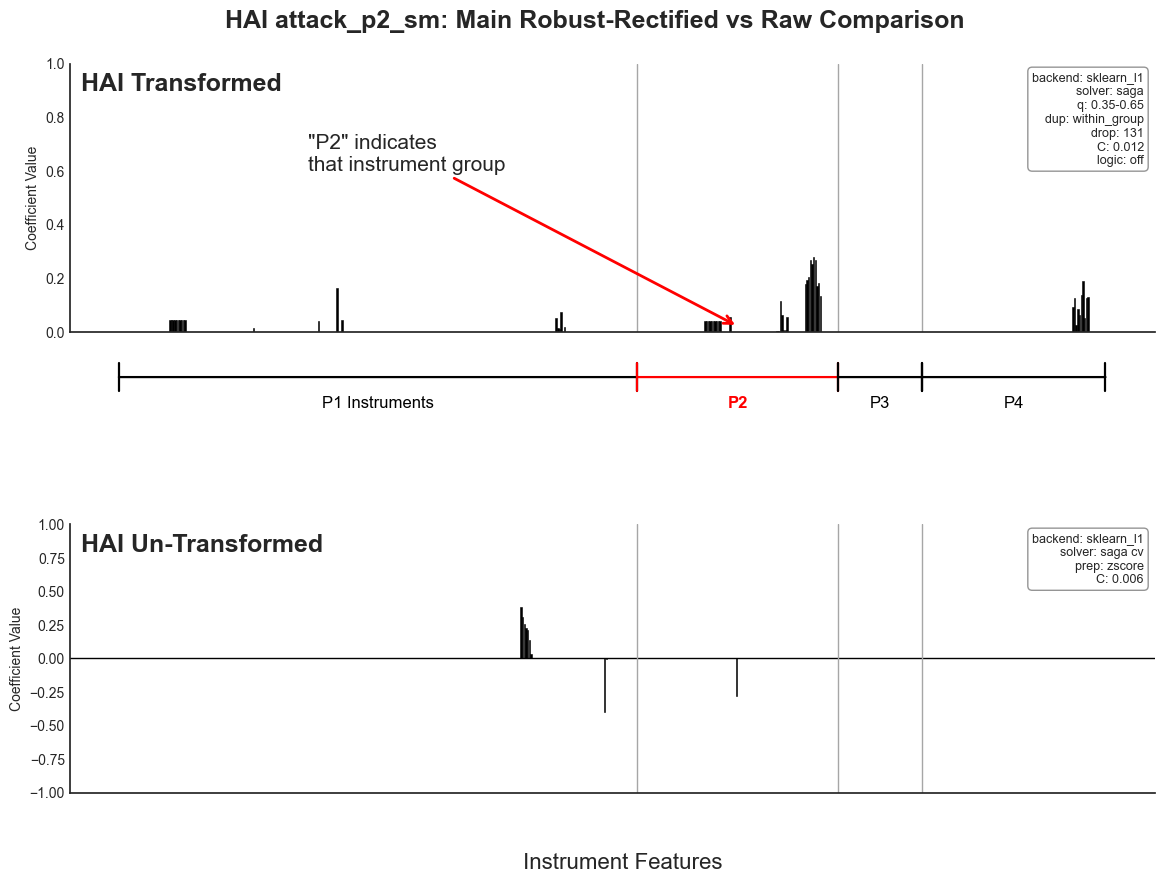

Saved figure to: C:\Users\jason\ODU\dissertation\notebooks\figures\hai_attack_p2_sm_cutlass_coefficients.png


In [6]:
main_transformed_summary = build_summary_text(
    [
        ('backend', TRANSFORMED_MODEL_BACKEND),
        ('solver', TRANSFORMED_SKLEARN_SOLVER if TRANSFORMED_MODEL_BACKEND == 'sklearn_l1' else 'CutlassLogisticCV'),
        ('q', summarize_quantile_bounds(RECTIFIER_KW)),
        ('dup', rect_result['duplicate_report']['mode']),
        ('drop', rect_result['duplicate_report']['duplicate_cols_removed']),
        ('C', FIXED_C_TRANSFORMED),
        ('logic', 'on' if USE_LOGIC_POLISH else 'off'),
    ]
)
main_raw_summary = build_summary_text(
    [
        ('backend', raw_result['metrics']['backend']),
        ('solver', raw_result['metrics']['solver']),
        ('prep', 'zscore'),
        ('C', raw_result['metrics']['chosen_C']),
    ]
)

figure = plot_hai_coefficient_figure(
    rect_result['coef'],
    raw_result['coef'],
    feature_order,
    highlight_group=PLOT_HIGHLIGHT_GROUP,
    figure_title=f'HAI {TARGET_KEY}{split_suffix}: Main Robust-Rectified vs Raw Comparison',
    transformed_summary=main_transformed_summary,
    raw_summary=main_raw_summary,
)

output_name = f'hai_{TARGET_KEY}{split_suffix}_cutlass_coefficients.png'
output_path = FIG_DIR / output_name
figure.savefig(output_path, dpi=200, bbox_inches='tight')
plt.show()
print('Saved figure to:', output_path)


,backend,solver,q,dup_mode,fit_features,duplicate_cols_removed,roc_auc,youden_j,chosen_C,nonzero_coef,wall_seconds,p2_share
pipeline,,,,,,,,,,,,
Robust quantile rectification,sklearn_l1,saga,0.35-0.65,within_group,459,131,0.9895,0.9296,0.012000,57,0.783,0.5991
Basic min/max rectification,sklearn_l1,saga,min/max,within_group,287,303,0.6345,-0.2093,0.012000,22,23.710,0.0000
Un-transformed baseline,sklearn_l1,saga cv,n/a,n/a,590,0,0.8833,0.4759,0.005995,12,374.051,0.1228


Robust quantile rectification                      \
                      nonzero_count   abs_sum   max_abs   
group                                                     
P2                               28  2.796680  0.279691   
P1                               19  0.853475  0.160921   
P4                               10  1.017908  0.189028   
P3                                0  0.000000  0.000000   

      Basic min/max rectification                      
                    nonzero_count   abs_sum   max_abs  
group                                                  
P2                              0  0.000000  0.000000  
P1                             17  3.166533  0.617520  
P4                              2  0.126767  0.074994  
P3                              3  0.336286  0.113579

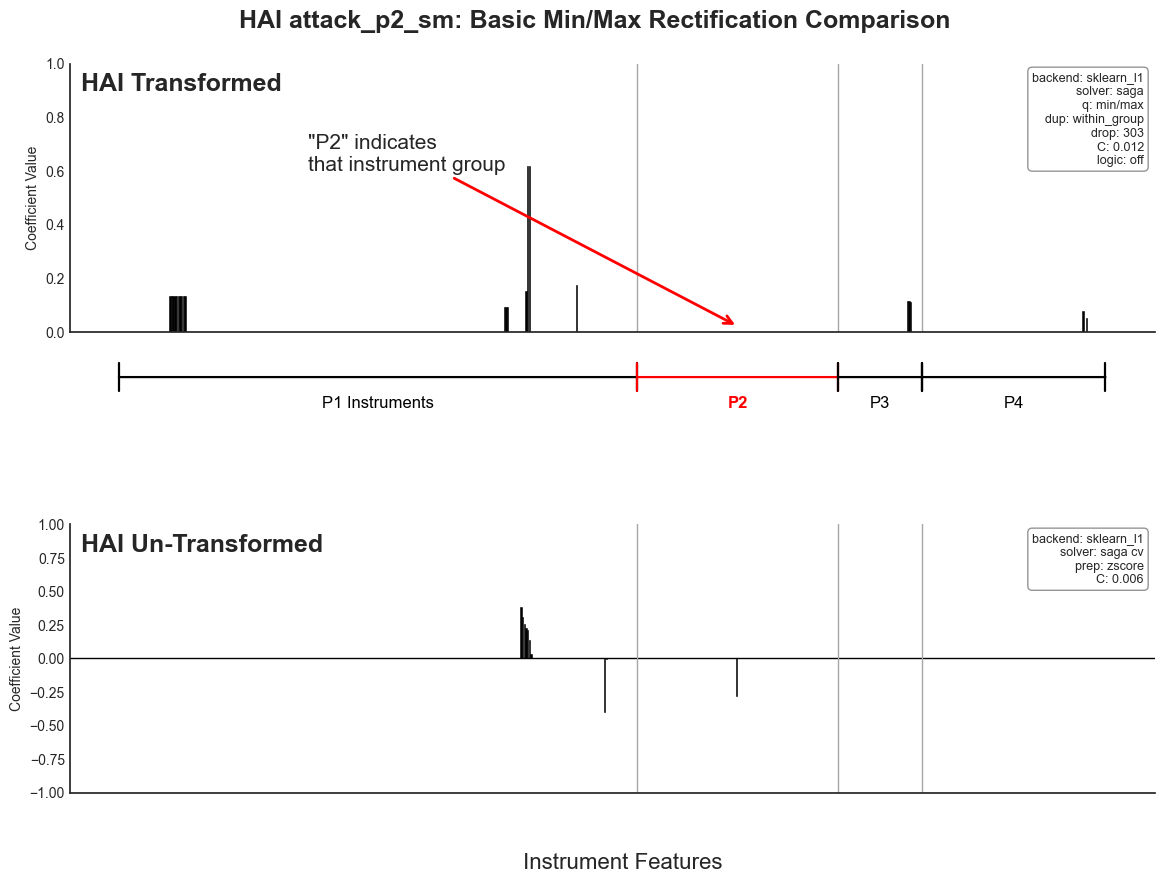

Saved figure to: C:\Users\jason\ODU\dissertation\notebooks\figures\hai_attack_p2_sm_basic_rectification_coefficients.png


In [7]:

# Rectification comparison: robust quantiles vs. basic min/max
BASIC_RECTIFIER_KW = {k: v for k, v in RECTIFIER_KW.items() if k != 'quantile_bounds'}
if 'quantile_bounds' not in RECTIFIER_KW:
    print('Current RECTIFIER_KW already uses basic min/max rectification.')

basic_rect_wall_start = perf_counter()
basic_design = prepare_rectified_design(
    X_train,
    y_train,
    X_test,
    rectifier_kw=BASIC_RECTIFIER_KW,
    duplicate_mode=DUPLICATE_CONSOLIDATION_MODE,
)
if TRANSFORMED_MODEL_BACKEND == 'sklearn_l1':
    basic_lr = LogisticRegression(
        penalty='l1',
        solver=TRANSFORMED_SKLEARN_SOLVER,
        C=float(FIXED_C_TRANSFORMED),
        max_iter=TRANSFORMED_SKLEARN_MAX_ITER,
        random_state=TRANSFORMED_SKLEARN_RANDOM_STATE,
        tol=TRANSFORMED_SKLEARN_TOL,
    )
    basic_lr.fit(basic_design['X_train_fit'], y_train)
    basic_solver_label = TRANSFORMED_SKLEARN_SOLVER
    basic_chosen_c = float(FIXED_C_TRANSFORMED)
else:
    basic_lr = CutlassLogisticCV(**build_cv_kwargs(FIXED_C_TRANSFORMED))
    basic_lr.fit(basic_design['X_train_fit'], y_train)
    basic_solver_label = 'CutlassLogisticCV'
    basic_chosen_c = float(basic_lr.C_)
basic_wall_seconds = perf_counter() - basic_rect_wall_start

basic_rect_result = build_transformed_result(
    design=basic_design,
    classifier=basic_lr,
    X_base_columns=list(X_train.columns),
    y_true=y_test,
    model_name='Transformed (Basic Rectification)',
    backend=TRANSFORMED_MODEL_BACKEND,
    chosen_c=basic_chosen_c,
    wall_seconds=basic_wall_seconds,
    solver_label=basic_solver_label,
)

rectification_comparison_df = pd.DataFrame(
    [
        {
            'pipeline': 'Robust quantile rectification',
            'backend': rect_result['metrics']['backend'],
            'solver': rect_result['metrics']['solver'],
            'q': summarize_quantile_bounds(RECTIFIER_KW),
            'dup_mode': rect_result['duplicate_report']['mode'],
            'fit_features': rect_result['duplicate_report']['fit_features'],
            'duplicate_cols_removed': rect_result['duplicate_report']['duplicate_cols_removed'],
            'roc_auc': rect_result['metrics']['roc_auc'],
            'youden_j': rect_result['metrics']['youden_j'],
            'chosen_C': rect_result['metrics']['chosen_C'],
            'nonzero_coef': rect_result['metrics']['nonzero_coef'],
            'wall_seconds': rect_result['metrics']['wall_seconds'],
            'p2_share': float(coefficient_group_share(rect_result['coef'], 'P2', feature_order)),
        },
        {
            'pipeline': 'Basic min/max rectification',
            'backend': basic_rect_result['metrics']['backend'],
            'solver': basic_rect_result['metrics']['solver'],
            'q': summarize_quantile_bounds(BASIC_RECTIFIER_KW),
            'dup_mode': basic_rect_result['duplicate_report']['mode'],
            'fit_features': basic_rect_result['duplicate_report']['fit_features'],
            'duplicate_cols_removed': basic_rect_result['duplicate_report']['duplicate_cols_removed'],
            'roc_auc': basic_rect_result['metrics']['roc_auc'],
            'youden_j': basic_rect_result['metrics']['youden_j'],
            'chosen_C': basic_rect_result['metrics']['chosen_C'],
            'nonzero_coef': basic_rect_result['metrics']['nonzero_coef'],
            'wall_seconds': basic_rect_result['metrics']['wall_seconds'],
            'p2_share': float(coefficient_group_share(basic_rect_result['coef'], 'P2', feature_order)),
        },
        {
            'pipeline': 'Un-transformed baseline',
            'backend': raw_result['metrics']['backend'],
            'solver': raw_result['metrics']['solver'],
            'q': 'n/a',
            'dup_mode': 'n/a',
            'fit_features': len(feature_order),
            'duplicate_cols_removed': 0,
            'roc_auc': raw_result['metrics']['roc_auc'],
            'youden_j': raw_result['metrics']['youden_j'],
            'chosen_C': raw_result['metrics']['chosen_C'],
            'nonzero_coef': raw_result['metrics']['nonzero_coef'],
            'wall_seconds': raw_result['metrics']['wall_seconds'],
            'p2_share': float(coefficient_group_share(raw_result['coef'], 'P2', feature_order)),
        },
    ]
).set_index('pipeline')
rectification_comparison_df = rectification_comparison_df.round(
    {'roc_auc': 4, 'youden_j': 4, 'chosen_C': 6, 'wall_seconds': 3, 'p2_share': 4}
)
display(rectification_comparison_df)

basic_vs_robust_group_summary = pd.concat(
    {
        'Robust quantile rectification': coefficient_group_summary(rect_result['coef']),
        'Basic min/max rectification': coefficient_group_summary(basic_rect_result['coef']),
    },
    axis=1,
)
display(basic_vs_robust_group_summary)

basic_transformed_summary = build_summary_text(
    [
        ('backend', TRANSFORMED_MODEL_BACKEND),
        ('solver', basic_solver_label),
        ('q', summarize_quantile_bounds(BASIC_RECTIFIER_KW)),
        ('dup', basic_rect_result['duplicate_report']['mode']),
        ('drop', basic_rect_result['duplicate_report']['duplicate_cols_removed']),
        ('C', basic_chosen_c),
        ('logic', 'on' if USE_LOGIC_POLISH else 'off'),
    ]
)
basic_raw_summary = build_summary_text(
    [
        ('backend', raw_result['metrics']['backend']),
        ('solver', raw_result['metrics']['solver']),
        ('prep', 'zscore'),
        ('C', raw_result['metrics']['chosen_C']),
    ]
)

basic_figure = plot_hai_coefficient_figure(
    basic_rect_result['coef'],
    raw_result['coef'],
    feature_order,
    highlight_group=PLOT_HIGHLIGHT_GROUP,
    figure_title=f'HAI {TARGET_KEY}{split_suffix}: Basic Min/Max Rectification Comparison',
    transformed_summary=basic_transformed_summary,
    raw_summary=basic_raw_summary,
)

basic_output_name = f'hai_{TARGET_KEY}{split_suffix}_basic_rectification_coefficients.png'
basic_output_path = FIG_DIR / basic_output_name
basic_figure.savefig(basic_output_path, dpi=200, bbox_inches='tight')
plt.show()
print('Saved figure to:', basic_output_path)


,backend,solver,fixed_C,view,logic_polish,rectifier_kw,duplicate_mode,expansion
pipeline,,,,,,,,
Tuned transformed,sklearn_l1,saga,0.012,effect_abs,False,"{'sdfilter': None, 'snap': 0.001, 'quantile_bo...",within_group,split_evenly
Un-optimized transformed,cutlass_l1,CutlassLogisticCV,0.020,effect_abs,False,"{'sdfilter': None, 'snap': 0.001, 'quantile_bo...",within_group,split_evenly


,model,backend,solver,roc_auc,youden_j,chosen_C,nonzero_coef,nonzero_coef_full,nonzero_coef_fit,wall_seconds,mode,expansion,input_features,fit_features,duplicate_groups,duplicate_cols_removed,cross_group_alias_classes
pipeline,,,,,,,,,,,,,,,,,
Tuned transformed,Transformed,sklearn_l1,saga,0.9895,0.9296,0.012,57,57,39,0.783,within_group,split_evenly,590,459,11,131,1
Un-optimized transformed,Transformed (Un-Optimized),cutlass_l1,CutlassLogisticCV,0.9924,0.9296,0.020,75,75,48,8.530,within_group,split_evenly,590,459,11,131,1


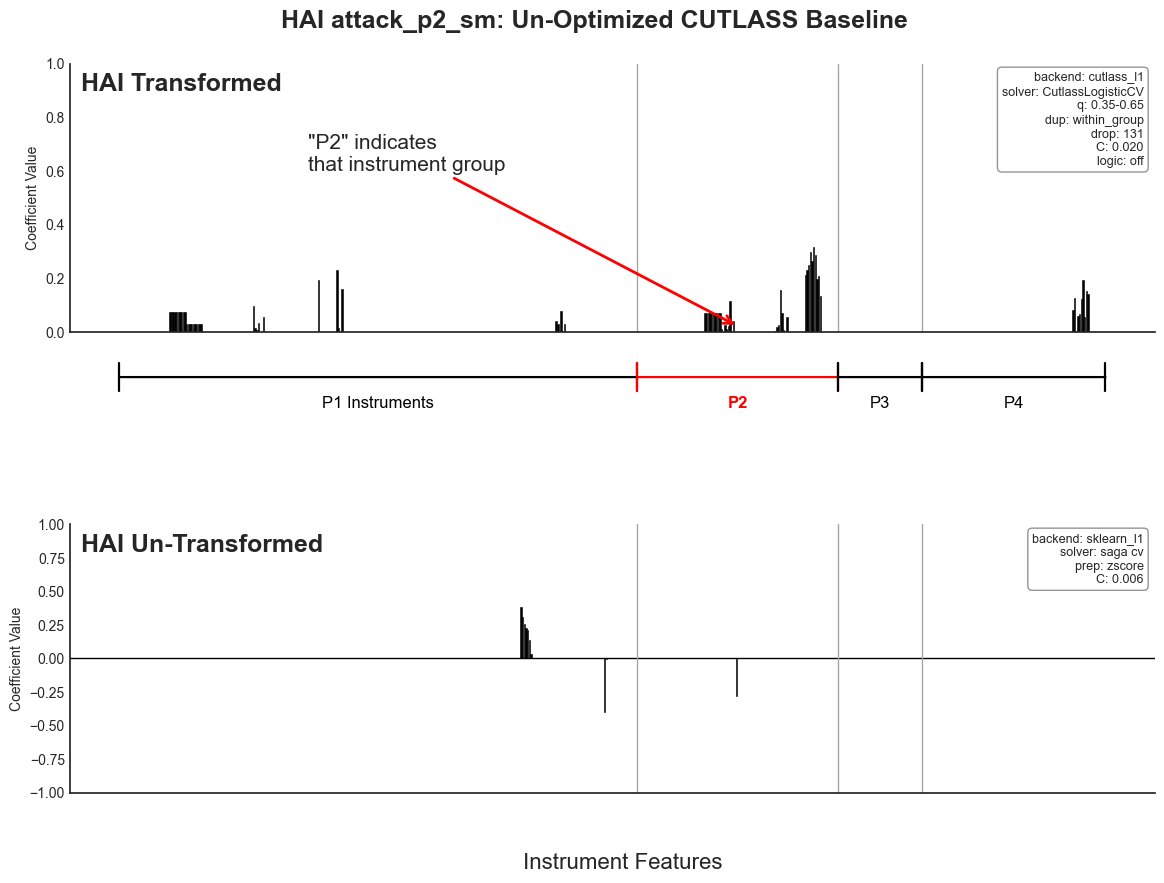

In [8]:

BASELINE_TRANSFORMED_CONFIG = {
    'backend': 'cutlass_l1',
    'solver': 'CutlassLogisticCV',
    'fixed_c': 0.02,
    'view': 'effect_abs',
    'logic_polish': False,
    'rectifier_kw': dict(RECTIFIER_KW),
    'duplicate_mode': DUPLICATE_CONSOLIDATION_MODE,
}

baseline_wall_start = perf_counter()
baseline_design = prepare_rectified_design(
    X_train,
    y_train,
    X_test,
    rectifier_kw=BASELINE_TRANSFORMED_CONFIG['rectifier_kw'],
    duplicate_mode=BASELINE_TRANSFORMED_CONFIG['duplicate_mode'],
)
baseline_lr = CutlassLogisticCV(
    **dict(
        CV_KW,
        logic_polish=BASELINE_TRANSFORMED_CONFIG['logic_polish'],
        **LOGIC_POLISH_KW,
        Cs=[float(BASELINE_TRANSFORMED_CONFIG['fixed_c'])],
        cv_rule='min',
    )
)
baseline_lr.fit(baseline_design['X_train_fit'], y_train)
baseline_wall_seconds = perf_counter() - baseline_wall_start

baseline_rect_result = build_transformed_result(
    design=baseline_design,
    classifier=baseline_lr,
    X_base_columns=list(X_train.columns),
    y_true=y_test,
    model_name='Transformed (Un-Optimized)',
    backend=BASELINE_TRANSFORMED_CONFIG['backend'],
    chosen_c=float(BASELINE_TRANSFORMED_CONFIG['fixed_c']),
    wall_seconds=baseline_wall_seconds,
    solver_label=BASELINE_TRANSFORMED_CONFIG['solver'],
    view=BASELINE_TRANSFORMED_CONFIG['view'],
)

pipeline_spec_df = pd.DataFrame(
    [
        {
            'pipeline': 'Tuned transformed',
            'backend': TRANSFORMED_MODEL_BACKEND,
            'solver': rect_result['metrics']['solver'],
            'fixed_C': FIXED_C_TRANSFORMED,
            'view': TRANSFORMED_VIEW,
            'logic_polish': USE_LOGIC_POLISH,
            'rectifier_kw': str(RECTIFIER_KW),
            'duplicate_mode': rect_result['duplicate_report']['mode'],
            'expansion': rect_result['duplicate_report']['expansion'],
        },
        {
            'pipeline': 'Un-optimized transformed',
            'backend': BASELINE_TRANSFORMED_CONFIG['backend'],
            'solver': BASELINE_TRANSFORMED_CONFIG['solver'],
            'fixed_C': BASELINE_TRANSFORMED_CONFIG['fixed_c'],
            'view': BASELINE_TRANSFORMED_CONFIG['view'],
            'logic_polish': BASELINE_TRANSFORMED_CONFIG['logic_polish'],
            'rectifier_kw': str(BASELINE_TRANSFORMED_CONFIG['rectifier_kw']),
            'duplicate_mode': baseline_rect_result['duplicate_report']['mode'],
            'expansion': baseline_rect_result['duplicate_report']['expansion'],
        },
    ]
).set_index('pipeline')
display(pipeline_spec_df)

pipeline_metric_df = pd.DataFrame(
    [
        {'pipeline': 'Tuned transformed', **rect_result['metrics']},
        {'pipeline': 'Un-optimized transformed', **baseline_rect_result['metrics']},
    ]
).set_index('pipeline')
pipeline_metric_df = pipeline_metric_df.round({'roc_auc': 4, 'youden_j': 4, 'chosen_C': 6, 'wall_seconds': 3})
display(pipeline_metric_df)

baseline_transformed_summary = build_summary_text(
    [
        ('backend', BASELINE_TRANSFORMED_CONFIG['backend']),
        ('solver', BASELINE_TRANSFORMED_CONFIG['solver']),
        ('q', summarize_quantile_bounds(BASELINE_TRANSFORMED_CONFIG['rectifier_kw'])),
        ('dup', baseline_rect_result['duplicate_report']['mode']),
        ('drop', baseline_rect_result['duplicate_report']['duplicate_cols_removed']),
        ('C', BASELINE_TRANSFORMED_CONFIG['fixed_c']),
        ('logic', 'on' if BASELINE_TRANSFORMED_CONFIG['logic_polish'] else 'off'),
    ]
)
baseline_raw_summary = build_summary_text(
    [
        ('backend', raw_result['metrics']['backend']),
        ('solver', raw_result['metrics']['solver']),
        ('prep', 'zscore'),
        ('C', raw_result['metrics']['chosen_C']),
    ]
)

baseline_figure = plot_hai_coefficient_figure(
    baseline_rect_result['coef'],
    raw_result['coef'],
    feature_order,
    highlight_group=PLOT_HIGHLIGHT_GROUP,
    figure_title=f'HAI {TARGET_KEY}{split_suffix}: Un-Optimized CUTLASS Baseline',
    transformed_summary=baseline_transformed_summary,
    raw_summary=baseline_raw_summary,
)
plt.show()


,backend,solver,fixed_C,dup_mode,fit_features,cosine_to_sklearn,top15_overlap_with_sklearn,p2_share,nonzero_coef,roc_auc,youden_j,wall_seconds
pipeline,,,,,,,,,,,,
Sklearn transformed (reference),sklearn_l1,saga,0.012,within_group,459,1.0000,1.0000,0.5991,57,0.9895,0.9296,0.783
CUTLASS full pipeline (baseline),cutlass_l1,CutlassLogisticCV,0.020,within_group,459,0.9594,0.7333,0.5489,75,0.9924,0.9296,8.530
CUTLASS full pipeline (winner),cutlass_l1,cd,0.010,within_group,459,0.9916,0.9333,0.5911,52,0.9875,0.9037,3.286


Sklearn transformed                     CUTLASS full pipeline (winner)  \
            nonzero_count   abs_sum   max_abs                  nonzero_count   
group                                                                          
P2                     28  2.796680  0.279691                             25   
P1                     19  0.853475  0.160921                             17   
P4                     10  1.017908  0.189028                             10   
P3                      0  0.000000  0.000000                              0   

                           
        abs_sum   max_abs  
group                      
P2     2.424105  0.257721  
P1     0.637954  0.103258  
P4     1.038664  0.192231  
P3     0.000000  0.000000

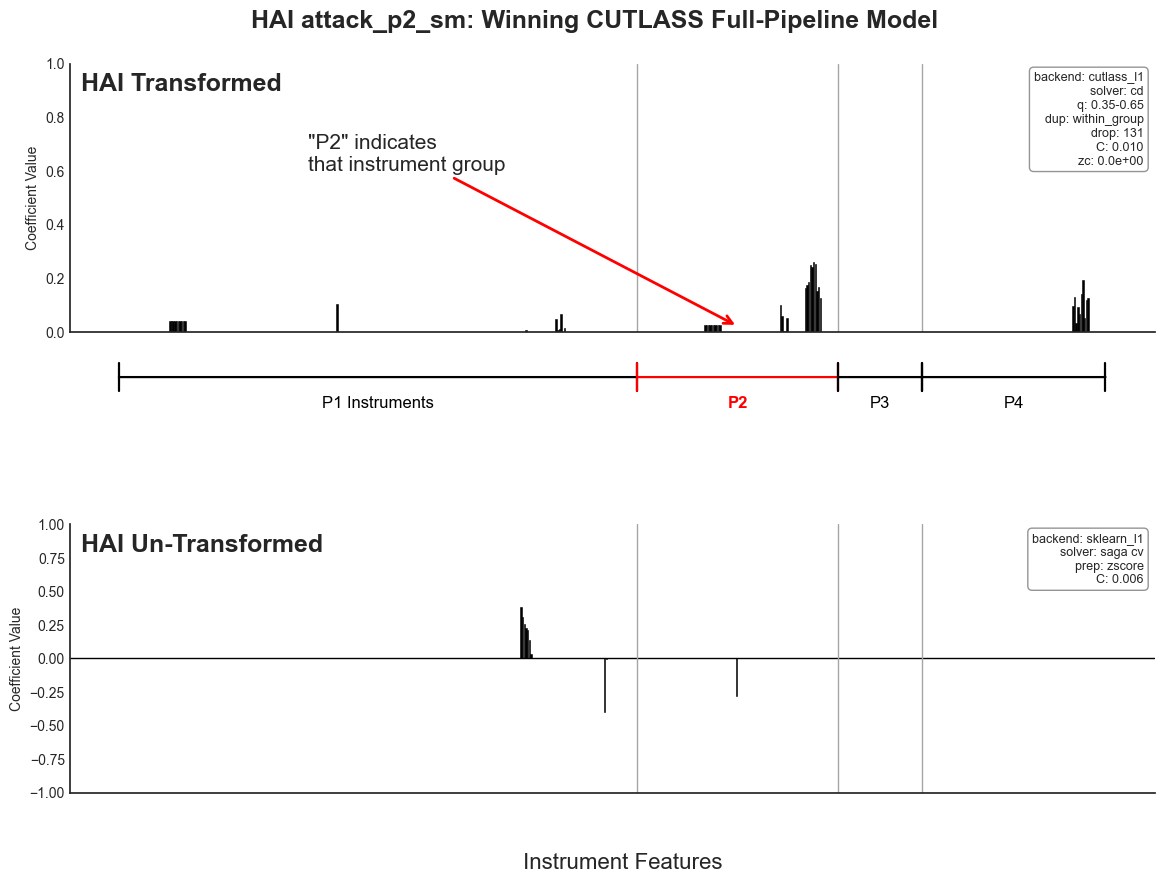

Saved figure to: C:\Users\jason\ODU\dissertation\notebooks\figures\hai_attack_p2_sm_cutlass_winning_full_pipeline_coefficients.png


In [9]:

TUNED_CUTLASS_FULL_PIPELINE_CONFIG = {
    'backend': 'cutlass_l1',
    'solver': TUNED_CUTLASS_FULL_PIPELINE_SOLVER,
    'fixed_c': TUNED_CUTLASS_FULL_PIPELINE_C,
    'tol': TUNED_CUTLASS_FULL_PIPELINE_TOL,
    'max_iter': TUNED_CUTLASS_FULL_PIPELINE_MAX_ITER,
    'zero_clamp': TUNED_CUTLASS_FULL_PIPELINE_ZERO_CLAMP,
    'view': 'effect_abs',
    'logic_polish': False,
    'rectifier_kw': dict(RECTIFIER_KW),
    'duplicate_mode': DUPLICATE_CONSOLIDATION_MODE,
}

cutlass_tuned_wall_start = perf_counter()
cutlass_tuned_design = prepare_rectified_design(
    X_train,
    y_train,
    X_test,
    rectifier_kw=TUNED_CUTLASS_FULL_PIPELINE_CONFIG['rectifier_kw'],
    duplicate_mode=TUNED_CUTLASS_FULL_PIPELINE_CONFIG['duplicate_mode'],
)
cutlass_tuned_lr = CutlassLogisticCV(
    **dict(
        CV_KW,
        solver=TUNED_CUTLASS_FULL_PIPELINE_CONFIG['solver'],
        tol=TUNED_CUTLASS_FULL_PIPELINE_CONFIG['tol'],
        max_iter=TUNED_CUTLASS_FULL_PIPELINE_CONFIG['max_iter'],
        zero_clamp=TUNED_CUTLASS_FULL_PIPELINE_CONFIG['zero_clamp'],
        logic_polish=TUNED_CUTLASS_FULL_PIPELINE_CONFIG['logic_polish'],
        **LOGIC_POLISH_KW,
        Cs=[float(TUNED_CUTLASS_FULL_PIPELINE_CONFIG['fixed_c'])],
        cv_rule='min',
    )
)
cutlass_tuned_lr.fit(cutlass_tuned_design['X_train_fit'], y_train)
cutlass_tuned_wall_seconds = perf_counter() - cutlass_tuned_wall_start

cutlass_tuned_rect_result = build_transformed_result(
    design=cutlass_tuned_design,
    classifier=cutlass_tuned_lr,
    X_base_columns=list(X_train.columns),
    y_true=y_test,
    model_name='Transformed (CUTLASS Winner)',
    backend=TUNED_CUTLASS_FULL_PIPELINE_CONFIG['backend'],
    chosen_c=float(TUNED_CUTLASS_FULL_PIPELINE_CONFIG['fixed_c']),
    wall_seconds=cutlass_tuned_wall_seconds,
    solver_label=TUNED_CUTLASS_FULL_PIPELINE_CONFIG['solver'],
    view=TUNED_CUTLASS_FULL_PIPELINE_CONFIG['view'],
)

def cosine_similarity_series(left: pd.Series, right: pd.Series) -> float:
    left_arr = left.reindex(feature_order).fillna(0.0).to_numpy(dtype=float)
    right_arr = right.reindex(feature_order).fillna(0.0).to_numpy(dtype=float)
    left_norm = np.linalg.norm(left_arr)
    right_norm = np.linalg.norm(right_arr)
    if left_norm == 0.0 or right_norm == 0.0:
        return 0.0
    return float(np.dot(left_arr / left_norm, right_arr / right_norm))


def top_k_overlap(reference: pd.Series, candidate: pd.Series, *, k: int = 15) -> float:
    reference_top = set(reference.sort_values(ascending=False).head(k).index)
    candidate_top = set(candidate.sort_values(ascending=False).head(k).index)
    return float(len(reference_top & candidate_top) / k)


def group_share(coef: pd.Series, group: str) -> float:
    return coefficient_group_share(coef, group, feature_order)


cutlass_alignment_df = pd.DataFrame(
    [
        {
            'pipeline': 'Sklearn transformed (reference)',
            'backend': TRANSFORMED_MODEL_BACKEND,
            'solver': TRANSFORMED_SKLEARN_SOLVER,
            'fixed_C': FIXED_C_TRANSFORMED,
            'dup_mode': rect_result['duplicate_report']['mode'],
            'fit_features': rect_result['duplicate_report']['fit_features'],
            'cosine_to_sklearn': 1.0,
            'top15_overlap_with_sklearn': 1.0,
            'p2_share': group_share(rect_result['coef'], 'P2'),
            'nonzero_coef': rect_result['metrics']['nonzero_coef'],
            'roc_auc': rect_result['metrics']['roc_auc'],
            'youden_j': rect_result['metrics']['youden_j'],
            'wall_seconds': rect_result['metrics']['wall_seconds'],
        },
        {
            'pipeline': 'CUTLASS full pipeline (baseline)',
            'backend': BASELINE_TRANSFORMED_CONFIG['backend'],
            'solver': BASELINE_TRANSFORMED_CONFIG['solver'],
            'fixed_C': BASELINE_TRANSFORMED_CONFIG['fixed_c'],
            'dup_mode': baseline_rect_result['duplicate_report']['mode'],
            'fit_features': baseline_rect_result['duplicate_report']['fit_features'],
            'cosine_to_sklearn': cosine_similarity_series(rect_result['coef'], baseline_rect_result['coef']),
            'top15_overlap_with_sklearn': top_k_overlap(rect_result['coef'], baseline_rect_result['coef'], k=15),
            'p2_share': group_share(baseline_rect_result['coef'], 'P2'),
            'nonzero_coef': baseline_rect_result['metrics']['nonzero_coef'],
            'roc_auc': baseline_rect_result['metrics']['roc_auc'],
            'youden_j': baseline_rect_result['metrics']['youden_j'],
            'wall_seconds': baseline_rect_result['metrics']['wall_seconds'],
        },
        {
            'pipeline': 'CUTLASS full pipeline (winner)',
            'backend': TUNED_CUTLASS_FULL_PIPELINE_CONFIG['backend'],
            'solver': TUNED_CUTLASS_FULL_PIPELINE_CONFIG['solver'],
            'fixed_C': TUNED_CUTLASS_FULL_PIPELINE_CONFIG['fixed_c'],
            'dup_mode': cutlass_tuned_rect_result['duplicate_report']['mode'],
            'fit_features': cutlass_tuned_rect_result['duplicate_report']['fit_features'],
            'cosine_to_sklearn': cosine_similarity_series(rect_result['coef'], cutlass_tuned_rect_result['coef']),
            'top15_overlap_with_sklearn': top_k_overlap(rect_result['coef'], cutlass_tuned_rect_result['coef'], k=15),
            'p2_share': group_share(cutlass_tuned_rect_result['coef'], 'P2'),
            'nonzero_coef': cutlass_tuned_rect_result['metrics']['nonzero_coef'],
            'roc_auc': cutlass_tuned_rect_result['metrics']['roc_auc'],
            'youden_j': cutlass_tuned_rect_result['metrics']['youden_j'],
            'wall_seconds': cutlass_tuned_rect_result['metrics']['wall_seconds'],
        },
    ]
).set_index('pipeline')
cutlass_alignment_df = cutlass_alignment_df.round({
    'fixed_C': 6,
    'cosine_to_sklearn': 4,
    'top15_overlap_with_sklearn': 4,
    'p2_share': 4,
    'roc_auc': 4,
    'youden_j': 4,
    'wall_seconds': 3,
})
display(cutlass_alignment_df)

cutlass_tuned_group_summary = pd.concat(
    {
        'Sklearn transformed': coefficient_group_summary(rect_result['coef']),
        'CUTLASS full pipeline (winner)': coefficient_group_summary(cutlass_tuned_rect_result['coef']),
    },
    axis=1,
)
display(cutlass_tuned_group_summary)

cutlass_tuned_transformed_summary = build_summary_text(
    [
        ('backend', TUNED_CUTLASS_FULL_PIPELINE_CONFIG['backend']),
        ('solver', TUNED_CUTLASS_FULL_PIPELINE_CONFIG['solver']),
        ('q', summarize_quantile_bounds(TUNED_CUTLASS_FULL_PIPELINE_CONFIG['rectifier_kw'])),
        ('dup', cutlass_tuned_rect_result['duplicate_report']['mode']),
        ('drop', cutlass_tuned_rect_result['duplicate_report']['duplicate_cols_removed']),
        ('C', TUNED_CUTLASS_FULL_PIPELINE_CONFIG['fixed_c']),
        ('zc', TUNED_CUTLASS_FULL_PIPELINE_CONFIG['zero_clamp']),
    ]
)
cutlass_tuned_raw_summary = build_summary_text(
    [
        ('backend', raw_result['metrics']['backend']),
        ('solver', raw_result['metrics']['solver']),
        ('prep', 'zscore'),
        ('C', raw_result['metrics']['chosen_C']),
    ]
)

cutlass_tuned_figure = plot_hai_coefficient_figure(
    cutlass_tuned_rect_result['coef'],
    raw_result['coef'],
    feature_order,
    highlight_group=PLOT_HIGHLIGHT_GROUP,
    figure_title=f'HAI {TARGET_KEY}{split_suffix}: Winning CUTLASS Full-Pipeline Model',
    transformed_summary=cutlass_tuned_transformed_summary,
    raw_summary=cutlass_tuned_raw_summary,
)
cutlass_tuned_output_name = f'hai_{TARGET_KEY}{split_suffix}_cutlass_winning_full_pipeline_coefficients.png'
cutlass_tuned_output_path = FIG_DIR / cutlass_tuned_output_name
cutlass_tuned_figure.savefig(cutlass_tuned_output_path, dpi=200, bbox_inches='tight')
plt.show()
print('Saved figure to:', cutlass_tuned_output_path)


,solver,fixed_C,logic_polish,p2_share,nonzero_coef,roc_auc,youden_j,wall_seconds
pipeline,,,,,,,,
Sklearn transformed (reference),saga,0.012,False,0.5991,57,0.9895,0.9296,0.783
CUTLASS full pipeline (winner),cd,0.010,False,0.5911,52,0.9875,0.9037,3.286
CUTLASS full pipeline (logic polished),cd + pre-redist,0.010,True,0.6316,37,0.9781,0.8963,3.261


CUTLASS full pipeline (winner)                      \
                       nonzero_count   abs_sum   max_abs   
group                                                      
P2                                25  2.424105  0.257721   
P1                                17  0.637954  0.103258   
P4                                10  1.038664  0.192231   
P3                                 0  0.000000  0.000000   

      CUTLASS full pipeline (logic polished)                  
                               nonzero_count abs_sum max_abs  
group                                                         
P2                                        21   120.0    10.0  
P1                                        11    20.0    10.0  
P4                                         5    50.0    10.0  
P3                                         0     0.0     0.0

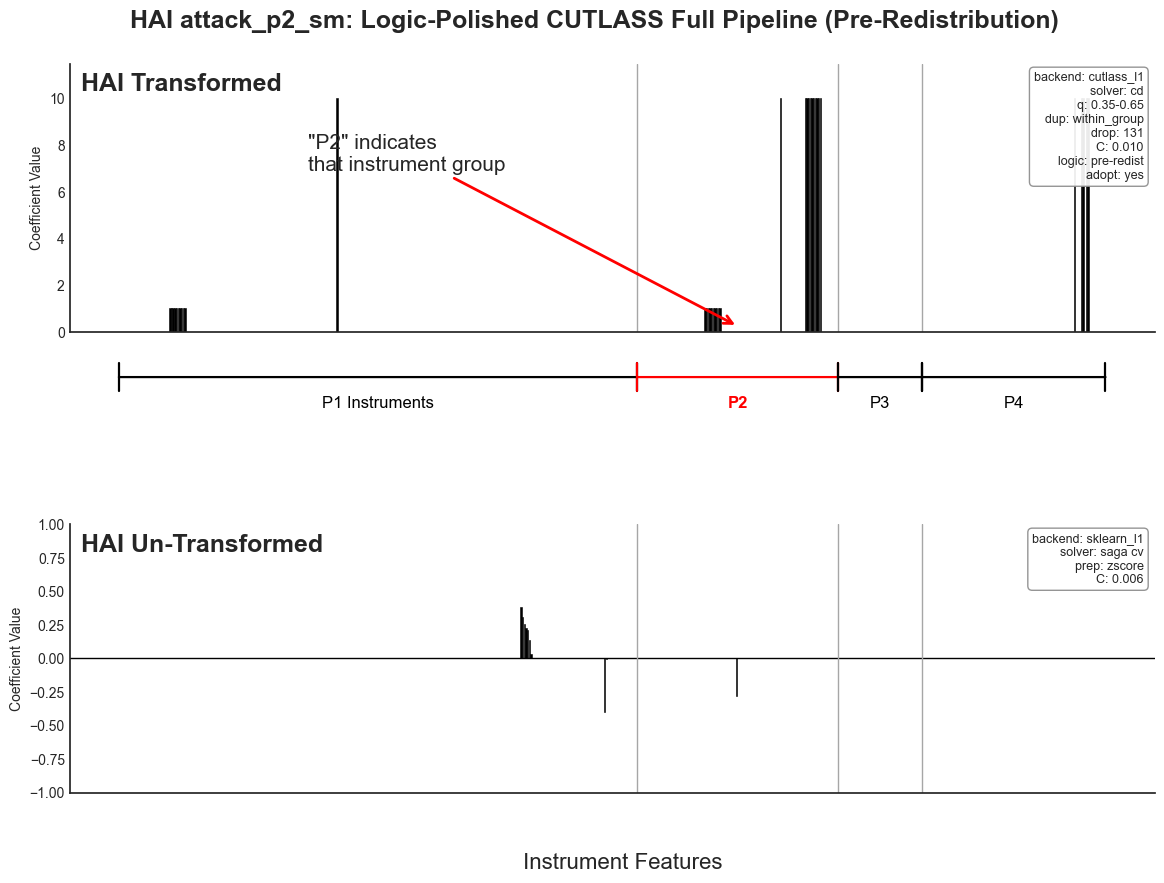

Saved figure to: C:\Users\jason\ODU\dissertation\notebooks\figures\hai_attack_p2_sm_cutlass_logic_polished_full_pipeline_coefficients.png


In [10]:
# Full CUTLASS pipeline with logic polishing, using pre-redistribution coefficients.
LOGIC_POLISHED_CUTLASS_CONFIG = {
    'backend': 'cutlass_l1',
    'solver': TUNED_CUTLASS_FULL_PIPELINE_CONFIG['solver'],
    'fixed_c': TUNED_CUTLASS_FULL_PIPELINE_CONFIG['fixed_c'],
    'tol': TUNED_CUTLASS_FULL_PIPELINE_CONFIG['tol'],
    'max_iter': TUNED_CUTLASS_FULL_PIPELINE_CONFIG['max_iter'],
    'zero_clamp': TUNED_CUTLASS_FULL_PIPELINE_CONFIG['zero_clamp'],
    'view': 'effect_abs',
    'logic_polish': True,
    'logic_stage': 'pre_redistribution',
    'rectifier_kw': dict(TUNED_CUTLASS_FULL_PIPELINE_CONFIG['rectifier_kw']),
    'duplicate_mode': TUNED_CUTLASS_FULL_PIPELINE_CONFIG['duplicate_mode'],
}

logic_polished_wall_start = perf_counter()
logic_polished_design = prepare_rectified_design(
    X_train,
    y_train,
    X_test,
    rectifier_kw=LOGIC_POLISHED_CUTLASS_CONFIG['rectifier_kw'],
    duplicate_mode=LOGIC_POLISHED_CUTLASS_CONFIG['duplicate_mode'],
)
logic_polished_lr = CutlassLogisticCV(
    **dict(
        CV_KW,
        solver=LOGIC_POLISHED_CUTLASS_CONFIG['solver'],
        tol=LOGIC_POLISHED_CUTLASS_CONFIG['tol'],
        max_iter=LOGIC_POLISHED_CUTLASS_CONFIG['max_iter'],
        zero_clamp=LOGIC_POLISHED_CUTLASS_CONFIG['zero_clamp'],
        logic_polish=LOGIC_POLISHED_CUTLASS_CONFIG['logic_polish'],
        **LOGIC_POLISH_KW,
        Cs=[float(LOGIC_POLISHED_CUTLASS_CONFIG['fixed_c'])],
        cv_rule='min',
    )
)
logic_polished_lr.fit(logic_polished_design['X_train_fit'], y_train)

logic_polished_wall_seconds = perf_counter() - logic_polished_wall_start

logic_polished_coef_fit = pd.Series(
    logic_polished_lr.coef_.ravel(),
    index=logic_polished_design['fit_feature_names'],
    name='coef',
)
logic_polished_adopted = bool(logic_polished_lr.logic_diag_.get('adopted', False)) if hasattr(logic_polished_lr, 'logic_diag_') else False

logic_polished_rect_result = build_transformed_result(
    design=logic_polished_design,
    classifier=logic_polished_lr,
    X_base_columns=list(X_train.columns),
    y_true=y_test,
    model_name='Transformed (CUTLASS Logic-Polished)',
    backend=LOGIC_POLISHED_CUTLASS_CONFIG['backend'],
    chosen_c=float(LOGIC_POLISHED_CUTLASS_CONFIG['fixed_c']),
    wall_seconds=logic_polished_wall_seconds,
    solver_label=f"{LOGIC_POLISHED_CUTLASS_CONFIG['solver']} + pre-redist",
    view=LOGIC_POLISHED_CUTLASS_CONFIG['view'],
)

logic_polished_comparison_df = pd.DataFrame(
    [
        {
            'pipeline': 'Sklearn transformed (reference)',
            'solver': rect_result['metrics']['solver'],
            'fixed_C': rect_result['metrics']['chosen_C'],
            'logic_polish': False,
            'p2_share': coefficient_group_share(rect_result['coef'], 'P2', feature_order),
            'nonzero_coef': rect_result['metrics']['nonzero_coef'],
            'roc_auc': rect_result['metrics']['roc_auc'],
            'youden_j': rect_result['metrics']['youden_j'],
            'wall_seconds': rect_result['metrics']['wall_seconds'],
        },
        {
            'pipeline': 'CUTLASS full pipeline (winner)',
            'solver': cutlass_tuned_rect_result['metrics']['solver'],
            'fixed_C': cutlass_tuned_rect_result['metrics']['chosen_C'],
            'logic_polish': False,
            'p2_share': coefficient_group_share(cutlass_tuned_rect_result['coef'], 'P2', feature_order),
            'nonzero_coef': cutlass_tuned_rect_result['metrics']['nonzero_coef'],
            'roc_auc': cutlass_tuned_rect_result['metrics']['roc_auc'],
            'youden_j': cutlass_tuned_rect_result['metrics']['youden_j'],
            'wall_seconds': cutlass_tuned_rect_result['metrics']['wall_seconds'],
        },
        {
            'pipeline': 'CUTLASS full pipeline (logic polished)',
            'solver': logic_polished_rect_result['metrics']['solver'],
            'fixed_C': logic_polished_rect_result['metrics']['chosen_C'],
            'logic_polish': True,
            'p2_share': coefficient_group_share(logic_polished_rect_result['coef'], 'P2', feature_order),
            'nonzero_coef': logic_polished_rect_result['metrics']['nonzero_coef'],
            'roc_auc': logic_polished_rect_result['metrics']['roc_auc'],
            'youden_j': logic_polished_rect_result['metrics']['youden_j'],
            'wall_seconds': logic_polished_rect_result['metrics']['wall_seconds'],
        },
    ]
).set_index('pipeline')
logic_polished_comparison_df = logic_polished_comparison_df.round(
    {'fixed_C': 6, 'p2_share': 4, 'roc_auc': 4, 'youden_j': 4, 'wall_seconds': 3}
)
display(logic_polished_comparison_df)

logic_polished_group_summary = pd.concat(
    {
        'CUTLASS full pipeline (winner)': coefficient_group_summary(cutlass_tuned_rect_result['coef']),
        'CUTLASS full pipeline (logic polished)': coefficient_group_summary(logic_polished_rect_result['coef']),
    },
    axis=1,
)
display(logic_polished_group_summary)

logic_polished_transformed_summary = build_summary_text(
    [
        ('backend', LOGIC_POLISHED_CUTLASS_CONFIG['backend']),
        ('solver', LOGIC_POLISHED_CUTLASS_CONFIG['solver']),
        ('q', summarize_quantile_bounds(LOGIC_POLISHED_CUTLASS_CONFIG['rectifier_kw'])),
        ('dup', logic_polished_rect_result['duplicate_report']['mode']),
        ('drop', logic_polished_rect_result['duplicate_report']['duplicate_cols_removed']),
        ('C', LOGIC_POLISHED_CUTLASS_CONFIG['fixed_c']),
        ('logic', 'pre-redist'),
        ('adopt', 'yes' if logic_polished_adopted else 'no'),
    ]
)
logic_polished_raw_summary = build_summary_text(
    [
        ('backend', raw_result['metrics']['backend']),
        ('solver', raw_result['metrics']['solver']),
        ('prep', 'zscore'),
        ('C', raw_result['metrics']['chosen_C']),
    ]
)

logic_polished_figure = plot_hai_coefficient_figure(
    logic_polished_rect_result['coef'],
    raw_result['coef'],
    feature_order,
    highlight_group=PLOT_HIGHLIGHT_GROUP,
    figure_title=f'HAI {TARGET_KEY}{split_suffix}: Logic-Polished CUTLASS Full Pipeline (Pre-Redistribution)',
    transformed_summary=logic_polished_transformed_summary,
    raw_summary=logic_polished_raw_summary,
)
logic_polished_output_path = FIG_DIR / f'hai_{TARGET_KEY}{split_suffix}_cutlass_logic_polished_full_pipeline_coefficients.png'
logic_polished_figure.savefig(logic_polished_output_path, dpi=200, bbox_inches='tight')
plt.show()
print('Saved figure to:', logic_polished_output_path)


,backend,roc_auc
model,,
HAI Un-Transformed,sklearn_l1,0.8833
HAI Transformed (sklearn),sklearn_l1,0.9895
HAI Transformed (CUTLASS winner),cutlass_l1,0.9875
HAI Logic Polished,cutlass_l1,0.9781


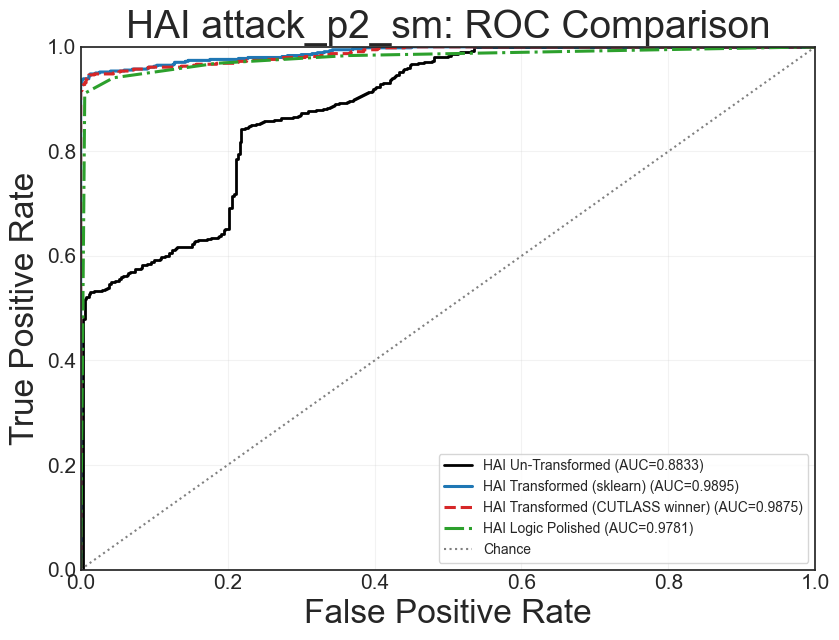

Saved figure to: C:\Users\jason\ODU\dissertation\notebooks\figures\hai_attack_p2_sm_roc_comparison.png


In [11]:
roc_comparison_df = pd.DataFrame(
    [
        {
            'model': 'HAI Un-Transformed',
            'backend': raw_result['metrics']['backend'],
            'roc_auc': raw_result['metrics']['roc_auc'],
        },
        {
            'model': 'HAI Transformed (sklearn)',
            'backend': rect_result['metrics']['backend'],
            'roc_auc': rect_result['metrics']['roc_auc'],
        },
        {
            'model': 'HAI Transformed (CUTLASS winner)',
            'backend': cutlass_tuned_rect_result['metrics']['backend'],
            'roc_auc': cutlass_tuned_rect_result['metrics']['roc_auc'],
        },
        {
            'model': 'HAI Logic Polished',
            'backend': logic_polished_rect_result['metrics']['backend'],
            'roc_auc': logic_polished_rect_result['metrics']['roc_auc'],
        },
    ]
).set_index('model').round({'roc_auc': 4})
display(roc_comparison_df)

roc_specs = [
    ('HAI Un-Transformed', raw_result['prob'], {'color': 'black', 'linestyle': '-', 'linewidth': 2.0}),
    ('HAI Transformed (sklearn)', rect_result['prob'], {'color': '#1f77b4', 'linestyle': '-', 'linewidth': 2.2}),
    ('HAI Transformed (CUTLASS winner)', cutlass_tuned_rect_result['prob'], {'color': '#d62728', 'linestyle': '--', 'linewidth': 2.2}),
    ('HAI Logic Polished', logic_polished_rect_result['prob'], {'color': '#2ca02c', 'linestyle': '-.', 'linewidth': 2.2}),
]

roc_fig, roc_ax = plt.subplots(figsize=(8.5, 6.5))
for label, prob, style in roc_specs:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_value = roc_auc_score(y_test, prob)
    roc_ax.plot(fpr, tpr, label=f'{label} (AUC={auc_value:.4f})', **style)

roc_ax.plot([0.0, 1.0], [0.0, 1.0], color='0.5', linestyle=':', linewidth=1.5, label='Chance')
roc_ax.set_xlim(0.0, 1.0)
roc_ax.set_ylim(0.0, 1.0)
roc_ax.set_xlabel('False Positive Rate', fontsize=24)
roc_ax.set_ylabel('True Positive Rate', fontsize=24)
roc_ax.set_title(f'HAI {TARGET_KEY}{split_suffix}: ROC Comparison', fontsize=28)
roc_ax.legend(loc='lower right', frameon=True)
roc_ax.grid(True, alpha=0.25)
roc_ax.tick_params(axis='both', labelsize=15)
roc_fig.tight_layout()

roc_output_path = FIG_DIR / f'hai_{TARGET_KEY}{split_suffix}_roc_comparison.png'
roc_fig.savefig(roc_output_path, dpi=200, bbox_inches='tight')
plt.show()
print('Saved figure to:', roc_output_path)


In [12]:
group_summary = pd.concat(
    {
        'Transformed': coefficient_group_summary(rect_result['coef']),
        'Un-Transformed': coefficient_group_summary(raw_result['coef']),
    },
    axis=1,
)
display(group_summary)

rect_top = rect_result['coef'].sort_values(ascending=False).head(20).rename('Transformed view')
rect_support_top = rect_result['coef_support'].sort_values(ascending=False).head(20).rename('Abs support')
rect_full_top = rect_result['coef_full'].sort_values(key=np.abs, ascending=False).head(20).rename('Expanded transformed')
raw_top = raw_result['coef'].sort_values(key=np.abs, ascending=False).head(20).rename('Un-Transformed')
display(pd.concat([rect_top, rect_support_top, rect_full_top, raw_top], axis=1))


Transformed                     Un-Transformed                    
      nonzero_count   abs_sum   max_abs  nonzero_count   abs_sum   max_abs
group                                                                     
P2               28  2.796680  0.279691              1  0.276672  0.276672
P1               19  0.853475  0.160921             11  1.975733  0.397214
P4               10  1.017908  0.189028              0  0.000000  0.000000
P3                0  0.000000  0.000000              0  0.000000  0.000000

,Transformed view,Abs support,Expanded transformed,Un-Transformed
P2_VYT02_06,0.279691,0.279691,-0.279691,NaN
P2_VYT02_07,0.267123,0.267123,-0.267123,NaN
P2_VYT02_04,0.265646,0.265646,-0.265646,NaN
P2_VYT02_05,0.253757,0.253757,-0.253757,NaN
P2_VYT02_03,0.203684,0.203684,-0.203684,NaN
P2_VYT02_02,0.190371,0.190371,-0.190371,NaN
P4_ST_PT01_07,0.189028,0.189028,0.189028,NaN
P2_VYT02_09,0.181842,0.181842,-0.181842,NaN
P2_VYT02_01,0.175696,0.175696,-0.175696,NaN
P2_VYT02_08,0.168604,0.168604,-0.168604,NaN


,k,J_k,J_k_smooth
0,1,0.583856,0.583856
1,2,0.565047,0.632445
2,3,0.748433,0.683647
3,4,0.737461,0.770637
4,5,0.826019,0.800679
5,6,0.838558,0.845873
6,7,0.873041,0.863375
7,8,0.878527,0.873302
8,9,0.868339,0.870951
9,10,0.865987,0.863375


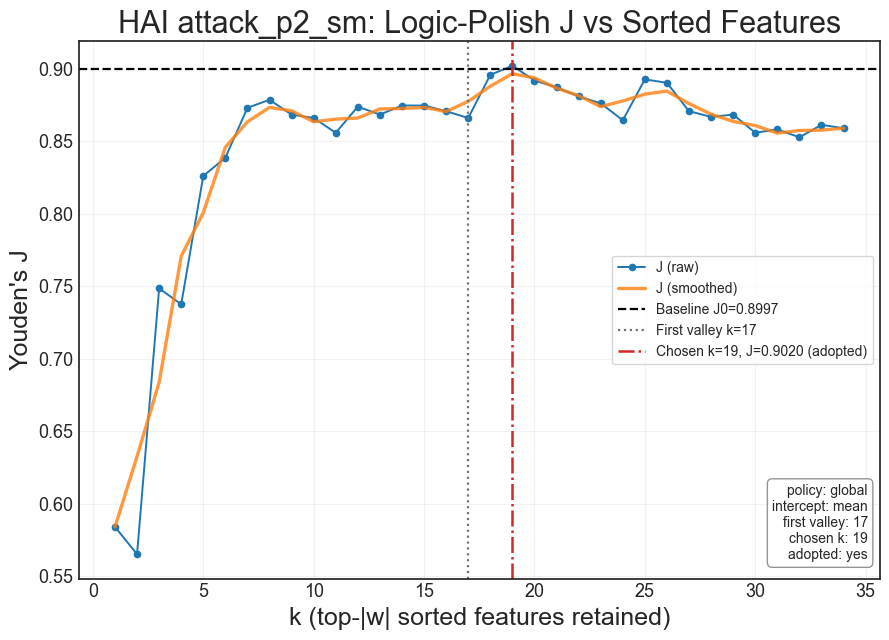

Saved figure to: C:\Users\jason\ODU\dissertation\notebooks\figures\hai_attack_p2_sm_logical_J_vs_k.png


In [13]:
logic_diag = getattr(logic_polished_lr, 'logic_diag_', None)
if not logic_diag or 'J_k' not in logic_diag:
    raise RuntimeError('Logic-polish diagnostics are not available. Run the logic-polished CUTLASS cell first.')

j0 = float(logic_diag['J0'])
j_k = np.asarray(logic_diag['J_k'], dtype=np.float64)
j_k_smooth = np.asarray(logic_diag.get('J_k_smooth', j_k), dtype=np.float64)
ks = np.arange(1, len(j_k) + 1)
k_first_min = int(logic_diag.get('k_first_min', 0))
k_chosen = int(logic_diag.get('k_chosen', 0))
j_chosen = float(logic_diag.get('J_chosen', np.nan))
adopted = bool(logic_diag.get('adopted', False))
policy = logic_diag.get('policy', 'global')
intercept_policy = logic_diag.get('intercept_policy', 'mean')

logic_curve_df = pd.DataFrame(
    {
        'k': ks,
        'J_k': j_k,
        'J_k_smooth': j_k_smooth,
    }
)
display(logic_curve_df.head(20))

j_curve_fig, j_curve_ax = plt.subplots(figsize=(9.0, 6.5))
j_curve_ax.plot(ks, j_k, marker='o', markersize=4.5, linewidth=1.4, color='#1f77b4', label='J (raw)')
j_curve_ax.plot(ks, j_k_smooth, linewidth=2.4, color='#ff7f0e', alpha=0.8, label='J (smoothed)')
j_curve_ax.axhline(j0, color='black', linestyle='--', linewidth=1.6, label=f'Baseline J0={j0:.4f}')
if k_first_min > 0:
    j_curve_ax.axvline(k_first_min, color='0.45', linestyle=':', linewidth=1.6, label=f'First valley k={k_first_min}')
if k_chosen > 0:
    chosen_label = f'Chosen k={k_chosen}, J={j_chosen:.4f}'
    if adopted:
        chosen_label += ' (adopted)'
    else:
        chosen_label += ' (not adopted)'
    j_curve_ax.axvline(k_chosen, color='#d62728', linestyle='-.', linewidth=1.8, label=chosen_label)

j_curve_ax.set_xlabel('k (top-|w| sorted features retained)', fontsize=18)
j_curve_ax.set_ylabel("Youden's J", fontsize=18)
j_curve_ax.set_title(
    f'HAI {TARGET_KEY}{split_suffix}: Logic-Polish J vs Sorted Features',
    fontsize=22,
)
j_curve_ax.tick_params(axis='both', labelsize=13)
j_curve_ax.grid(True, alpha=0.25)
j_curve_ax.legend(loc='best', frameon=True)

summary_text = '\n'.join(
    [
        f'policy: {policy}',
        f'intercept: {intercept_policy}',
        f'first valley: {k_first_min if k_first_min > 0 else "n/a"}',
        f'chosen k: {k_chosen if k_chosen > 0 else "n/a"}',
        f'adopted: {"yes" if adopted else "no"}',
    ]
)
j_curve_ax.text(
    0.985,
    0.03,
    summary_text,
    transform=j_curve_ax.transAxes,
    ha='right',
    va='bottom',
    fontsize=10,
    bbox=dict(boxstyle='round,pad=0.35', fc='white', ec='0.55', alpha=0.92),
)

j_curve_fig.tight_layout()
j_curve_output_path = FIG_DIR / f'hai_{TARGET_KEY}{split_suffix}_logical_J_vs_k.png'
j_curve_fig.savefig(j_curve_output_path, dpi=200, bbox_inches='tight')
plt.show()
print('Saved figure to:', j_curve_output_path)
